### Importing the Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report, recall_score, f1_score, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

### Reading and Analyzing of the Datasets

In [2]:
heart_dataset1 = pd.read_csv("Heart Attack Data Set.csv")
df1 = heart_dataset1.copy()
df1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df1.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
for i in list(df1.columns):
    print("{} -- {}".format(i, df1[i].value_counts().shape[0]))

age -- 41
sex -- 2
cp -- 4
trestbps -- 49
chol -- 152
fbs -- 2
restecg -- 3
thalach -- 91
exang -- 2
oldpeak -- 40
slope -- 3
ca -- 5
thal -- 4
target -- 2


In [7]:
heart_dataset2 = pd.read_csv("heart.csv")
df2 = heart_dataset2.copy()
df2.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [8]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [10]:
df2 = df2.drop_duplicates()
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [11]:
df2.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [12]:
for i in list(df2.columns):
    print("{} -- {}".format(i, df2[i].value_counts().shape[0]))

age -- 41
sex -- 2
cp -- 4
trestbps -- 49
chol -- 152
fbs -- 2
restecg -- 3
thalach -- 91
exang -- 2
oldpeak -- 40
slope -- 3
ca -- 5
thal -- 4
target -- 2


### Merging the datasets and Analyzing the Merged Dataset

In [13]:
combined_df = pd.concat([df1, df2], ignore_index= True)
combined_df.head()
combined_df.to_excel("combined_df.xlsx", index= False)

In [14]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       605 non-null    int64  
 1   sex       605 non-null    int64  
 2   cp        605 non-null    int64  
 3   trestbps  605 non-null    int64  
 4   chol      605 non-null    int64  
 5   fbs       605 non-null    int64  
 6   restecg   605 non-null    int64  
 7   thalach   605 non-null    int64  
 8   exang     605 non-null    int64  
 9   oldpeak   605 non-null    float64
 10  slope     605 non-null    int64  
 11  ca        605 non-null    int64  
 12  thal      605 non-null    int64  
 13  target    605 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 66.3 KB


### Dropping Duplicates

In [15]:
cleaned_df = combined_df.drop_duplicates()
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [16]:
cleaned_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [17]:
cleaned_df.to_excel("cleaned_df.xlsx", index= False)

### Outlier Detection

In [18]:
numeric_list = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df_numeric = cleaned_df.loc[:, numeric_list]
df_numeric.head()

,age,trestbps,chol,thalach,oldpeak
0,63,145,233,150,2.3
1,37,130,250,187,3.5
2,41,130,204,172,1.4
3,56,120,236,178,0.8
4,57,120,354,163,0.6


In [19]:
df_numeric.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [20]:
# outlier detection
for i in numeric_list:
    
    # IQR
    Q1 = np.percentile(cleaned_df.loc[:, i],25)
    Q3 = np.percentile(cleaned_df.loc[:, i],75)
    
    IQR = Q3 - Q1
    
    print("Old shape: ", cleaned_df.loc[:, i].shape)
    
    # upper bound
    upper = np.where(cleaned_df.loc[:, i] >= (Q3 + 1.5 * IQR))
    
    # lower bound
    lower = np.where(cleaned_df.loc[:, i] <= (Q1 - 1.5 * IQR))
    
    print("{} -- {}".format(upper, lower))
    
    try:
        cleaned_df.drop(upper[0], inplace = True)
    except: print("KeyError: {} not found in axis".format(upper[0]))
    
    try:
        cleaned_df.drop(lower[0], inplace = True)
    except:  print("KeyError: {} not found in axis".format(lower[0]))
        
    print("New shape: ", cleaned_df.shape)

Old shape:  (302,)
(array([], dtype=int64),) -- (array([], dtype=int64),)
New shape:  (302, 14)
Old shape:  (302,)
(array([  8, 101, 110, 152, 194, 202, 222, 227, 240, 247, 259, 265, 291],
      dtype=int64),) -- (array([], dtype=int64),)
New shape:  (289, 14)
Old shape:  (289,)
(array([ 27,  84,  95, 213, 236], dtype=int64),) -- (array([], dtype=int64),)
New shape:  (284, 14)
Old shape:  (284,)
(array([], dtype=int64),) -- (array([228, 254, 278], dtype=int64),)
New shape:  (281, 14)
Old shape:  (281,)
(array([194, 209, 210, 211, 233, 273], dtype=int64),) -- (array([], dtype=int64),)
KeyError: [194 209 210 211 233 273] not found in axis
New shape:  (281, 14)


### Categorical Feature Analysis

In [21]:
categorical_list = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]

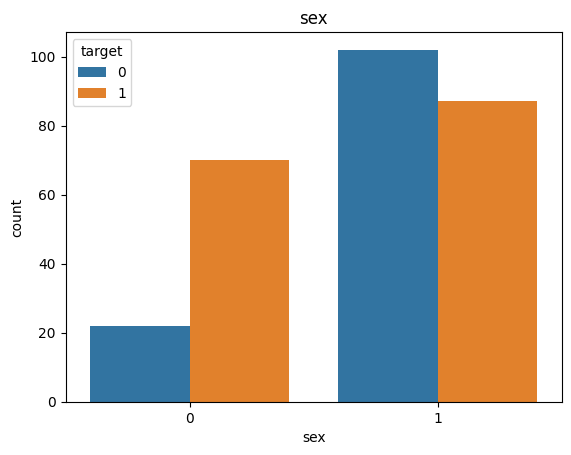

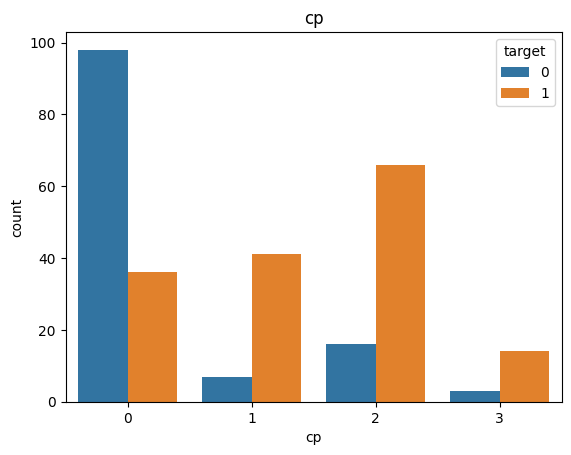

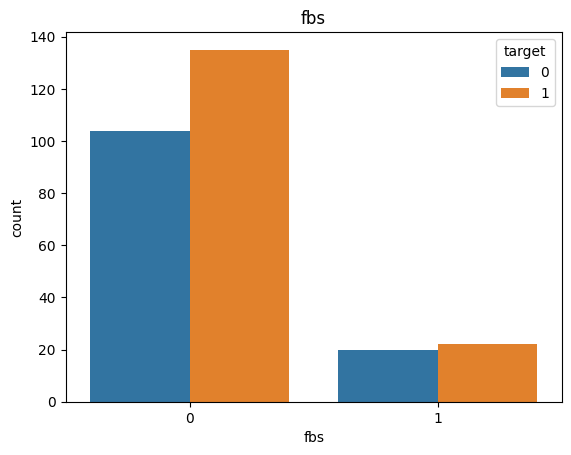

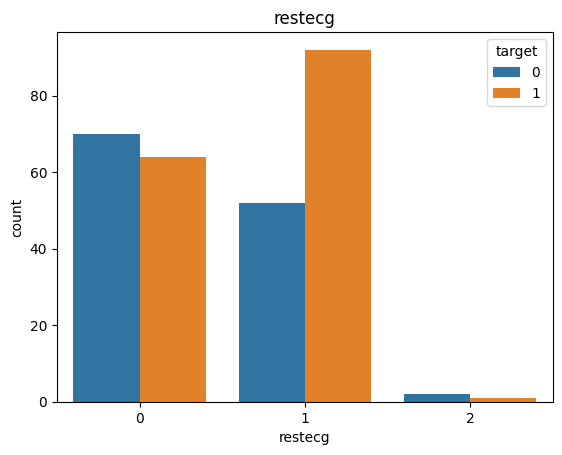

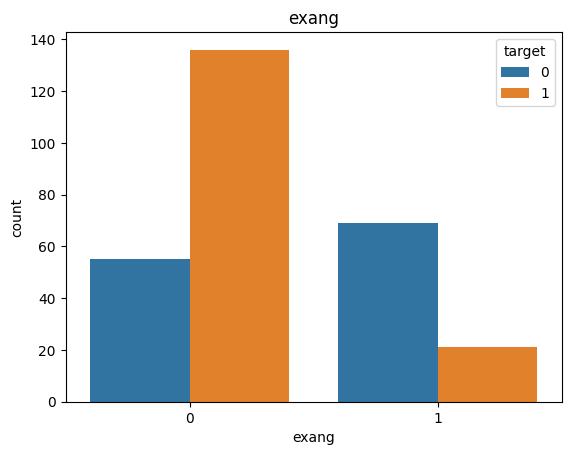

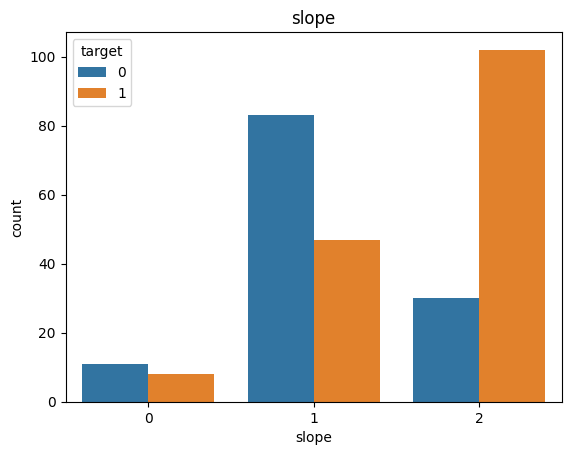

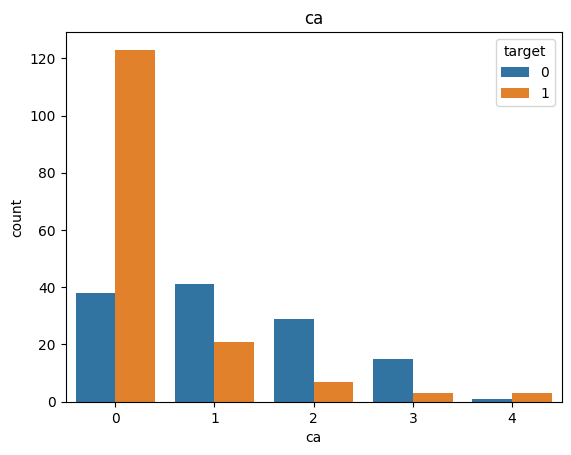

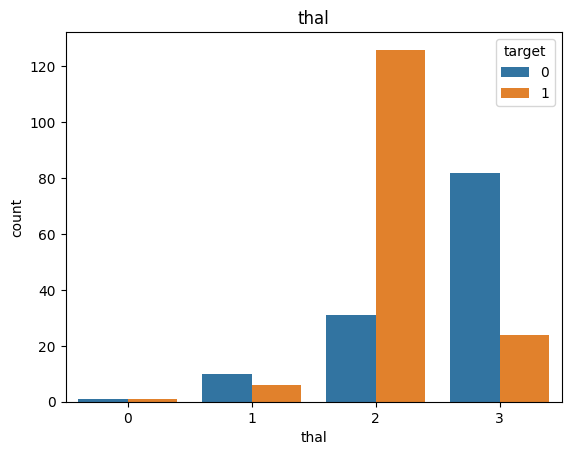

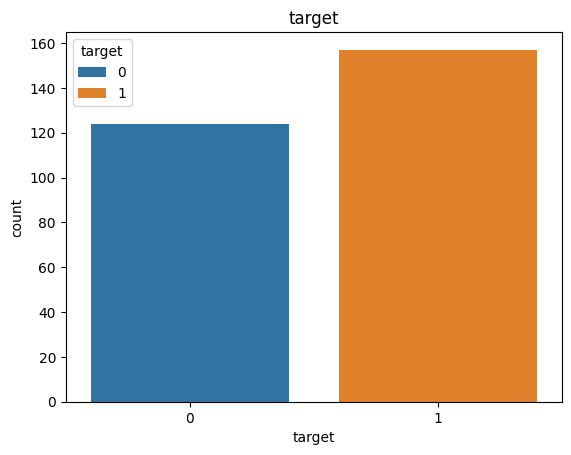

In [22]:
df_categoric = cleaned_df.loc[:, categorical_list]
for i in categorical_list:
    plt.figure()
    sns.countplot(x = i, data = df_categoric, hue = "target")
    plt.title(i)

### Numeric Feature Analysis

In [23]:
numeric_list = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]

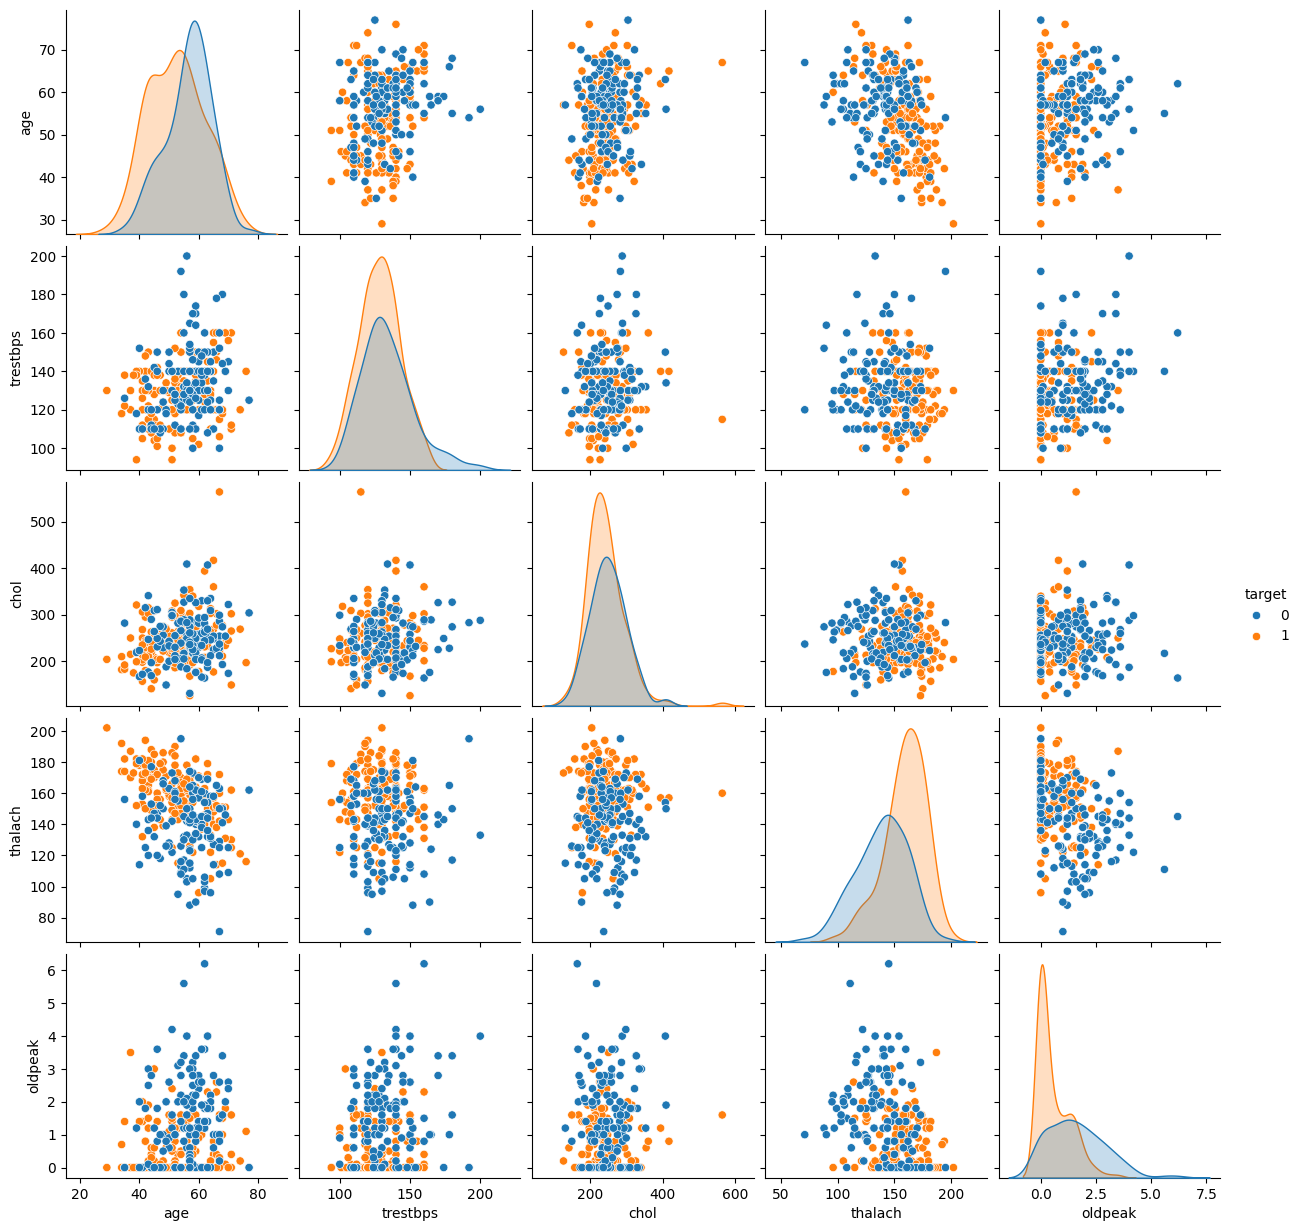

In [24]:
df_numeric = cleaned_df.loc[:, numeric_list]
sns.pairplot(data = df_numeric, hue = "target", diag_kind = "kde")

### Boxplot Analysis

In [25]:
df_dummy = pd.DataFrame(cleaned_df, columns= numeric_list[:-2])
df_dummy.head()

,age,trestbps,chol,thalach
0,63,145,233,150
1,37,130,250,187
2,41,130,204,172
3,56,120,236,178
4,57,120,354,163


In [26]:
df_dummy = pd.concat([df_dummy, cleaned_df.loc[:, "target"]], axis = 1)
df_dummy.head()

,age,trestbps,chol,thalach,target
0,63,145,233,150,1
1,37,130,250,187,1
2,41,130,204,172,1
3,56,120,236,178,1
4,57,120,354,163,1


In [27]:
data_melted = pd.melt(df_dummy, id_vars = "target", var_name = "features", value_name = "value")
data_melted.head(20)

,target,features,value
0,1,age,63
1,1,age,37
2,1,age,41
3,1,age,56
4,1,age,57
5,1,age,57
6,1,age,56
7,1,age,44
8,1,age,57
9,1,age,54


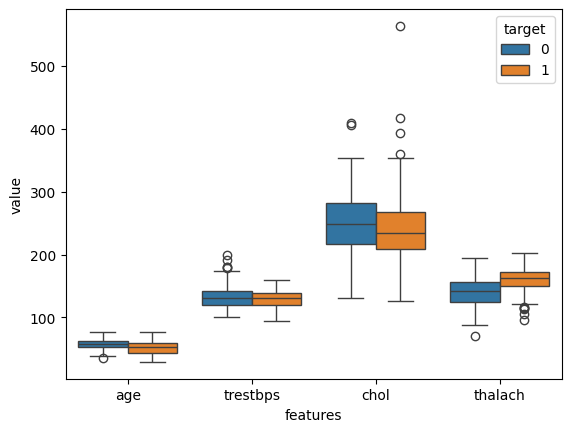

In [28]:
plt.figure()
sns.boxplot(x = "features", y = "value", hue = "target", data = data_melted)
plt.show();

### Swarmplot Analysis

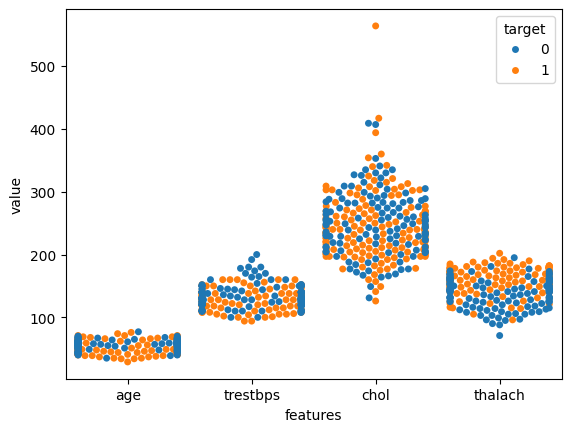

In [29]:
plt.figure()
sns.swarmplot(x = "features", y = "value", hue = "target", data = data_melted)
plt.show();

### Catplot Analysis

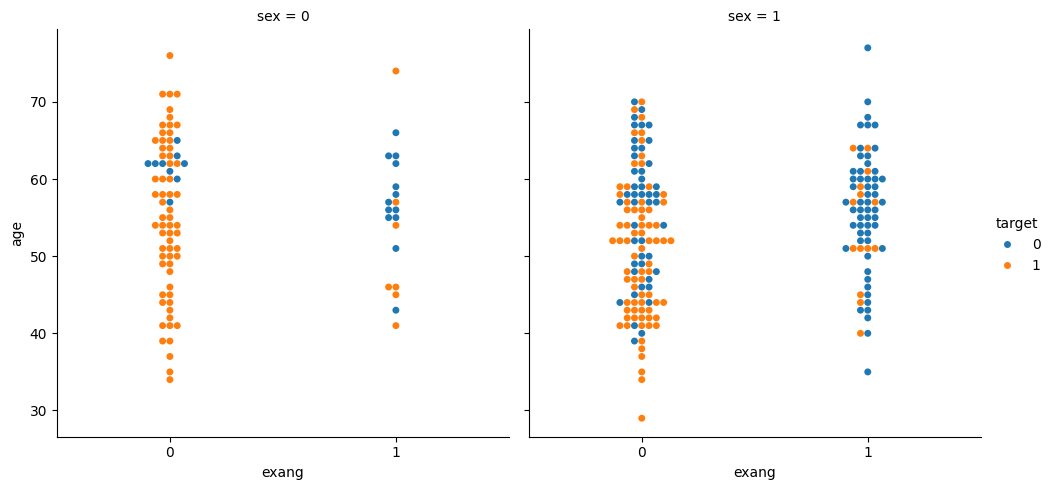

In [30]:
sns.catplot(x = "exang", y = "age", hue = "target", col = "sex", kind = "swarm", data = cleaned_df)
plt.show();

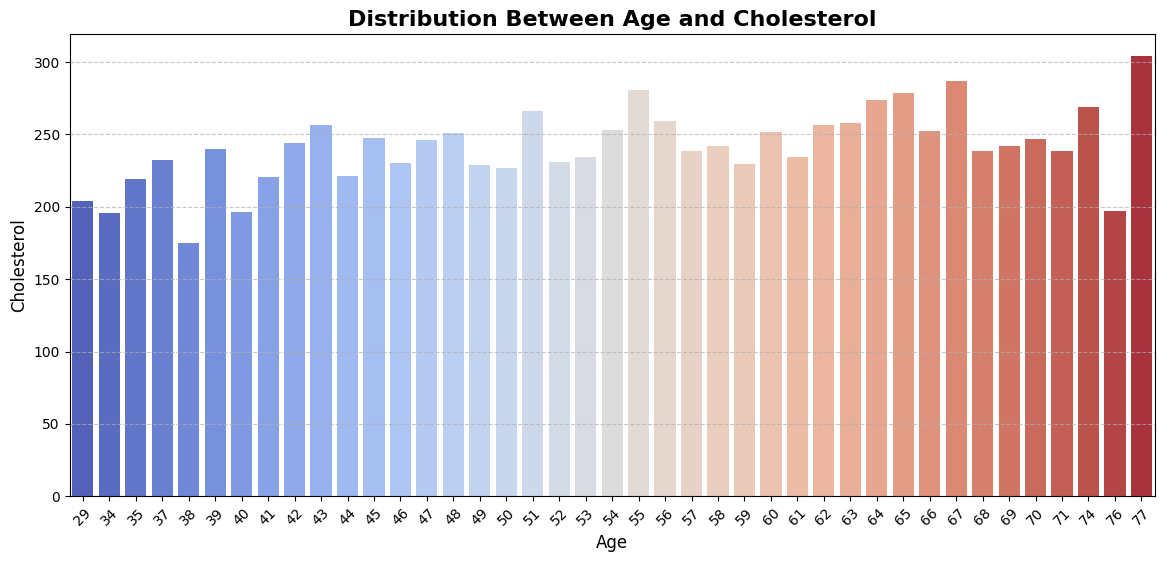

In [31]:
#distribution between age and cholestoral
plt.figure(figsize=(14,6))
sns.barplot(x="age", y="chol", data=cleaned_df, palette="coolwarm", ci=None)
plt.title("Distribution Between Age and Cholesterol", fontsize=16, weight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Cholesterol", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


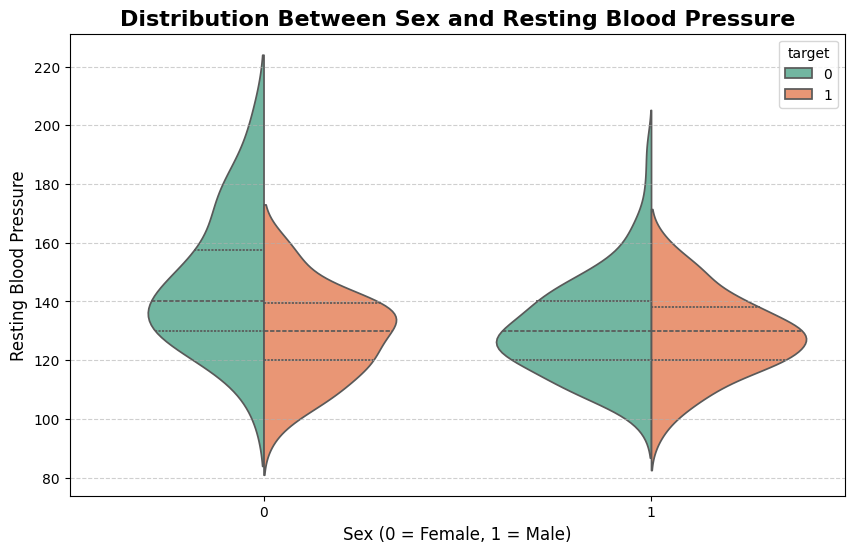

In [32]:
#distribution between sex and resting blood pressure
plt.figure(figsize=(10,6))
sns.violinplot(
    x="sex", 
    y="trestbps", 
    hue="target", 
    data=cleaned_df, 
    palette="Set2",   
    split=True,       
    inner="quartile"  
)
plt.title("Distribution Between Sex and Resting Blood Pressure", fontsize=16, weight="bold")
plt.xlabel("Sex (0 = Female, 1 = Male)", fontsize=12)
plt.ylabel("Resting Blood Pressure", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

### Checking Correlations

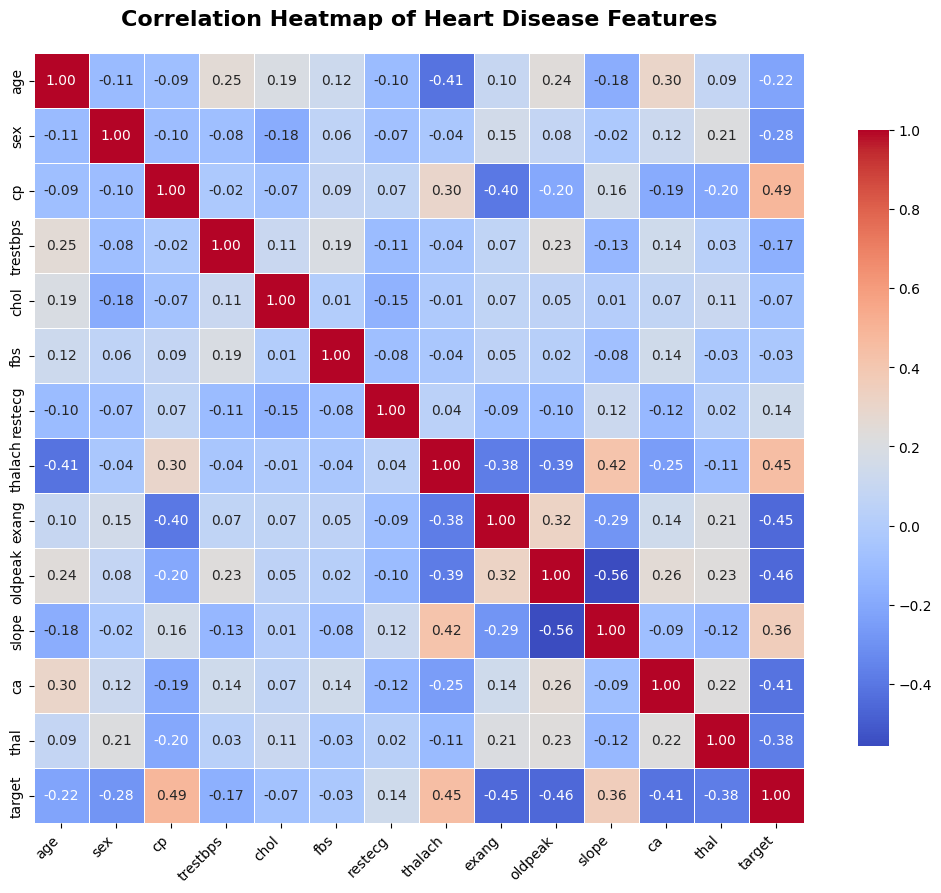

In [33]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    cleaned_df.corr(), 
    annot=True, 
    fmt=".2f", 
    linewidths=.7, 
    cmap="coolwarm",      
    cbar_kws={'shrink': 0.8},  
    square=True           
)
plt.title("Correlation Heatmap of Heart Disease Features", fontsize=16, weight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.show()

### Modelling

In [34]:
model_df = cleaned_df.copy()

In [35]:
model_df = pd.get_dummies(model_df, columns= categorical_list[:-1], drop_first= True, dtype= float)

In [36]:
model_df.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,63,145,233,150,2.3,1,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,37,130,250,187,3.5,1,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,41,130,204,172,1.4,1,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,56,120,236,178,0.8,1,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,57,120,354,163,0.6,1,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [37]:
x = model_df.drop(['target'], axis= 1)
y = model_df[['target']]

### Train-Test Split

In [77]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.25, random_state= 42)
print("x_train: {}".format(x_train.shape))
print("x_test: {}".format(x_test.shape))
print("y_train: {}".format(y_train.shape))
print("y_test: {}".format(y_test.shape))

x_train: (210, 22)
x_test: (71, 22)
y_train: (210, 1)
y_test: (71, 1)


### Scaling

In [78]:
scaler = StandardScaler()
scaler

StandardScaler()

In [79]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### Logistic Regression

In [80]:
log = LogisticRegression()
log

LogisticRegression()

In [81]:
log_model = log.fit(x_train, y_train)

In [82]:
y_pred_log = log_model.predict(x_test)
print("Accuracy Rate of Logistic Regression Model => {}".format(accuracy_score(y_pred_log, y_test)))
print("Precision => {}".format(precision_score(y_test, y_pred_log)))
print("Recall => {}".format(recall_score(y_test, y_pred_log)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_log)))
print(classification_report(y_pred_log, y_test))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_log))

Accuracy Rate of Logistic Regression Model => 0.8873239436619719
Precision => 0.9024390243902439
Recall => 0.9024390243902439
F1-Score => 0.9024390243902439
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        30
           1       0.90      0.90      0.90        41

    accuracy                           0.89        71
   macro avg       0.88      0.88      0.88        71
weighted avg       0.89      0.89      0.89        71


Confusion Matrix => 
 [[26  4]
 [ 4 37]]


### Roc Curve

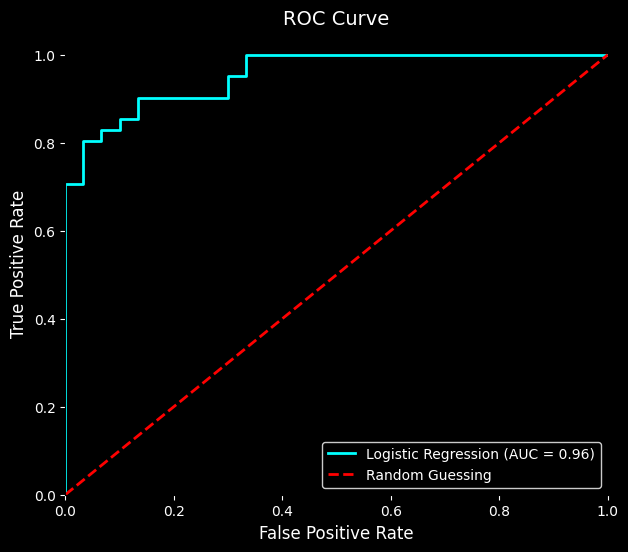

In [83]:
logit_roc_auc = roc_auc_score(y_test, log_model.predict_proba(x_test)[:, 1])
fpr, tpr, thresholds = roc_curve(y_test, log_model.predict_proba(x_test)[:, 1])

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="cyan", lw=2, 
         label='Logistic Regression (AUC = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Guessing")

plt.gca().set_facecolor("black")
plt.gcf().patch.set_facecolor("black")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", color="white", fontsize=12)
plt.ylabel("True Positive Rate", color="white", fontsize=12)
plt.title("ROC Curve", color="white", fontsize=14)

plt.legend(loc="lower right", facecolor="black", edgecolor="white", labelcolor="white")
plt.tick_params(axis='x', colors='white')
plt.tick_params(axis='y', colors='white')

plt.show()

### KNN

In [84]:
knn = KNeighborsClassifier()
knn

KNeighborsClassifier()

In [85]:
knn_model = knn.fit(x_train, y_train)
knn_model

KNeighborsClassifier()

In [86]:
y_pred_knn = knn_model.predict(x_test)
print("Accuracy rate of KNN Model => {}".format(accuracy_score(y_test, y_pred_knn)))
print("Precision => {}".format(precision_score(y_test, y_pred_knn)))
print("Recall => {}".format(recall_score(y_test, y_pred_knn)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_knn)))
print(classification_report(y_test, y_pred_knn))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_knn))

Accuracy rate of KNN Model => 0.8450704225352113
Precision => 0.875
Recall => 0.8536585365853658
F1-Score => 0.8641975308641975
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        30
           1       0.88      0.85      0.86        41

    accuracy                           0.85        71
   macro avg       0.84      0.84      0.84        71
weighted avg       0.85      0.85      0.85        71


Confusion Matrix => 
 [[25  5]
 [ 6 35]]


### SVM

In [87]:
svc = SVC()
svc

SVC()

In [88]:
svc_model = svc.fit(x_train, y_train)
svc_model

SVC()

In [89]:
y_pred_svc = svc_model.predict(x_test)
print("Accuracy Rate of SVM Model => {}".format(accuracy_score(y_test, y_pred_svc)))
print("Precision => {}".format(precision_score(y_test, y_pred_svc)))
print("Recall => {}".format(recall_score(y_test, y_pred_svc)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_svc)))
print(classification_report(y_pred_svc, y_test))
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_svc))

Accuracy Rate of SVM Model => 0.8450704225352113
Precision => 0.875
Recall => 0.8536585365853658
F1-Score => 0.8641975308641975
              precision    recall  f1-score   support

           0       0.83      0.81      0.82        31
           1       0.85      0.88      0.86        40

    accuracy                           0.85        71
   macro avg       0.84      0.84      0.84        71
weighted avg       0.84      0.85      0.84        71

Confusion Matrix => 
 [[25  5]
 [ 6 35]]


### Decision Tree

In [90]:
dt = DecisionTreeClassifier()
dt

DecisionTreeClassifier()

In [91]:
dt_model = dt.fit(x_train, y_train)
dt_model

DecisionTreeClassifier()

In [92]:
y_pred_dt = dt_model.predict(x_test)
print("Accuracy of Decision Tree Model => {}".format(accuracy_score(y_test, y_pred_dt)))
print("Precision => {}".format(precision_score(y_test, y_pred_dt)))
print("Recall => {}".format(recall_score(y_test, y_pred_dt)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_dt)))
print(classification_report(y_test, y_pred_dt))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_dt))

Accuracy of Decision Tree Model => 0.7746478873239436
Precision => 0.8205128205128205
Recall => 0.7804878048780488
F1-Score => 0.8
              precision    recall  f1-score   support

           0       0.72      0.77      0.74        30
           1       0.82      0.78      0.80        41

    accuracy                           0.77        71
   macro avg       0.77      0.77      0.77        71
weighted avg       0.78      0.77      0.78        71


Confusion Matrix => 
 [[23  7]
 [ 9 32]]


### Random Forest

In [93]:
rf = RandomForestClassifier(random_state= 42)
rf

RandomForestClassifier(random_state=42)

In [94]:
rf_model = rf.fit(x_train, y_train)
rf_model

RandomForestClassifier(random_state=42)

In [95]:
y_pred_rf = rf_model.predict(x_test)
print("Accuracy Rate of Random Forest Model => {}".format(accuracy_score(y_test, y_pred_rf)))
print("Precision => {}".format(precision_score(y_test, y_pred_rf)))
print("Recall => {}".format(recall_score(y_test, y_pred_rf)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_rf)))
print(classification_report(y_test, y_pred_rf))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_rf))

Accuracy Rate of Random Forest Model => 0.8028169014084507
Precision => 0.8857142857142857
Recall => 0.7560975609756098
F1-Score => 0.8157894736842105
              precision    recall  f1-score   support

           0       0.72      0.87      0.79        30
           1       0.89      0.76      0.82        41

    accuracy                           0.80        71
   macro avg       0.80      0.81      0.80        71
weighted avg       0.82      0.80      0.80        71


Confusion Matrix => 
 [[26  4]
 [10 31]]


### Ridge

In [96]:
ridge = RidgeClassifier()
ridge

RidgeClassifier()

In [97]:
ridge_model = ridge.fit(x_train, y_train)
ridge_model

RidgeClassifier()

In [98]:
y_pred_ridge = ridge_model.predict(x_test)
print("Accuracy Rate of Ridge Model => {}".format(accuracy_score(y_test, y_pred_ridge)))
print("Precision => {}".format(precision_score(y_test, y_pred_ridge)))
print("Recall => {}".format(recall_score(y_test, y_pred_ridge)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_ridge)))
print(classification_report(y_test, y_pred_ridge))
print()
print("Confussion Matrix => \n", confusion_matrix(y_test, y_pred_ridge))

Accuracy Rate of Ridge Model => 0.8873239436619719
Precision => 0.9024390243902439
Recall => 0.9024390243902439
F1-Score => 0.9024390243902439
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        30
           1       0.90      0.90      0.90        41

    accuracy                           0.89        71
   macro avg       0.88      0.88      0.88        71
weighted avg       0.89      0.89      0.89        71


Confussion Matrix => 
 [[26  4]
 [ 4 37]]


### Light GbM

In [99]:
lgbm = LGBMClassifier()
lgbm

LGBMClassifier()

In [100]:
lgbm_model = lgbm.fit(x_train, y_train)
lgbm_model

[LightGBM] [Info] Number of positive: 116, number of negative: 94
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000951 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 234
[LightGBM] [Info] Number of data points in the train set: 210, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.552381 -> initscore=0.210295
[LightGBM] [Info] Start training from score 0.210295
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

LGBMClassifier()

In [101]:
y_pred_lgbm = lgbm_model.predict(x_test)
print("Accuracy Rate of Light GBM Model => {}".format(accuracy_score(y_test, y_pred_lgbm)))
print("Precision => {}".format(precision_score(y_test, y_pred_lgbm)))
print("Recall => {}".format(recall_score(y_test, y_pred_lgbm)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_lgbm)))
print(classification_report(y_test, y_pred_lgbm))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_lgbm))

Accuracy Rate of Light GBM Model => 0.7746478873239436
Precision => 0.8205128205128205
Recall => 0.7804878048780488
F1-Score => 0.8
              precision    recall  f1-score   support

           0       0.72      0.77      0.74        30
           1       0.82      0.78      0.80        41

    accuracy                           0.77        71
   macro avg       0.77      0.77      0.77        71
weighted avg       0.78      0.77      0.78        71


Confusion Matrix => 
 [[23  7]
 [ 9 32]]


### XGBoost

In [102]:
xgb = XGBClassifier()
xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [103]:
xgb_model = xgb.fit(x_train, y_train)
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [104]:
y_pred_xgb = xgb_model.predict(x_test)
print("Accuracy Score of XGBoost Model => {}".format(accuracy_score(y_test, y_pred_xgb)))
print("Precision => {}".format(precision_score(y_test, y_pred_xgb)))
print("Recall => {}".format(recall_score(y_test, y_pred_xgb)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_xgb)))
print(classification_report(y_test, y_pred_xgb))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_xgb))

Accuracy Score of XGBoost Model => 0.8028169014084507
Precision => 0.8648648648648649
Recall => 0.7804878048780488
F1-Score => 0.8205128205128205
              precision    recall  f1-score   support

           0       0.74      0.83      0.78        30
           1       0.86      0.78      0.82        41

    accuracy                           0.80        71
   macro avg       0.80      0.81      0.80        71
weighted avg       0.81      0.80      0.80        71


Confusion Matrix => 
 [[25  5]
 [ 9 32]]


## Model Tuning

### Logistic Regression

In [74]:
log_params = {
    "penalty": ['l1', 'l2'],
    "C": [0.0001, 0.01, 0.1, 1, 10, 100]
}

In [75]:
log_model_cv = GridSearchCV(log, log_params, cv= 10)
log_model_cv.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.0001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2']})

In [76]:
print("Best parameters: " + str(log_model_cv.best_params_))

Best parameters: {'C': 1, 'penalty': 'l2'}


In [ ]:
log_tuned = LogisticRegression(C= 1, penalty= 'l2')
log_model_tuned = log_tuned.fit(x_train, y_train)
log_model_tuned

LogisticRegression(C=1)

In [78]:
y_pred_log_tuned = log_model_tuned.predict(x_test)
print("Accuracy Rate of Tuned Model => {}".format(accuracy_score(y_test, y_pred_log_tuned)))
print("Previous Accuracy => {}".format(accuracy_score(y_test, y_pred_log)))

Accuracy Rate of Tuned Model => 0.9310344827586207
Previous Accuracy => 0.9310344827586207


### KNN

In [79]:
nlist = []
for i in range(1, 11):
    nlist.append(i)

knn_params = {
    "n_neighbors": nlist,
    "weights": ['uniform', 'distance']
}

In [ ]:
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid= knn_params, cv= 10)
knn_cv.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'weights': ['uniform', 'distance']})

In [81]:
print(knn_cv.best_params_)

{'n_neighbors': 8, 'weights': 'distance'}


In [ ]:
knn_tuned = KNeighborsClassifier(n_neighbors= 8, weights= "distance")
knn_model_tuned = knn_tuned.fit(x_train, y_train)
knn_model_tuned

KNeighborsClassifier(n_neighbors=8, weights='distance')

In [ ]:
y_pred_knn_tuned = knn_model_tuned.predict(x_test)
print("Accuracy rate of tuned model => {}".format(accuracy_score(y_test, y_pred_knn_tuned)))
print("Previous accuracy  => {}".format(accuracy_score(y_test, y_pred_knn)))

Accuracy rate of tuned model => 0.7931034482758621
Precious accuracy 0.7931034482758621


### SVM

In [84]:
svm_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

In [ ]:
svm = SVC()
svm_cv = GridSearchCV(svm, param_grid= svm_params, cv = 10, n_jobs= -1, verbose= 2)
svm_cv.fit(x_train, y_train)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


GridSearchCV(cv=10, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             verbose=2)

In [86]:
print(svm_cv.best_params_)

{'C': 10, 'kernel': 'rbf'}


In [ ]:
svm_tuned = SVC(C= 10, kernel= 'rbf')
svc_model_tuned = svm_tuned.fit(x_train, y_train)
svc_model_tuned

SVC(C=10)

In [88]:
y_pred_svc_tuned = svc_model_tuned.predict(x_test)
print("Accuracy of tuned model => {}".format(accuracy_score(y_test, y_pred_svc_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_svc)))

Accuracy of tuned model => 0.8275862068965517
Previous accuracy => 0.8275862068965517


### Decision Tree

In [89]:
dt_params = {"max_depth": np.arange(2, 11),
             "max_features": np.arange(2, 15),
             "min_samples_split": [2, 5, 10, 20]}

In [ ]:
dt = DecisionTreeClassifier()
dt_cv = GridSearchCV(dt, param_grid= dt_params, cv = 10, n_jobs= -1, verbose= 2)
dt_cv.fit(x_train, y_train)

Fitting 10 folds for each of 468 candidates, totalling 4680 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'max_features': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                         'min_samples_split': [2, 5, 10, 20]},
             verbose=2)

In [91]:
print(dt_cv.best_params_)

{'max_depth': 10, 'max_features': 11, 'min_samples_split': 2}


In [ ]:
dt_tuned = DecisionTreeClassifier(max_depth= 10, max_features= 10, min_samples_split= 5)
dt_model_tuned = dt_tuned.fit(x_train, y_train)
dt_model_tuned

DecisionTreeClassifier(max_depth=10, max_features=10, min_samples_split=5)

In [ ]:
y_pred_dt_tuned = dt_model_tuned.predict(x_test)
print("Accuracy of tuned model => {}".format(accuracy_score(y_test, y_pred_dt_tuned)))
print("Previous Accuracy => {}".format(accuracy_score(y_test, y_pred_dt)))

Accuracy of tuned model => 0.8620689655172413
Precious Accuracy => 0.7931034482758621


### Random Forest

In [94]:
rf_params = {
    "max_depth": np.arange(2, 11),
    "max_features": np.arange(2, 15),
    "n_estimators": [10, 50, 100, 250, 500, 1000],
    "min_samples_split": [2, 5, 10, 20]
}
rf = RandomForestClassifier()
rf_cv = GridSearchCV(rf, param_grid= rf_params, cv = 10, n_jobs= -1, verbose= 2)
rf_cv.fit(x_train, y_train)

Fitting 10 folds for each of 2808 candidates, totalling 28080 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'max_features': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                         'min_samples_split': [2, 5, 10, 20],
                         'n_estimators': [10, 50, 100, 250, 500, 1000]},
             verbose=2)

In [95]:
print(rf_cv.best_params_)

{'max_depth': 9, 'max_features': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [96]:
rf_tuned = RandomForestClassifier(max_depth= 5, max_features= 2, min_samples_split= 20, n_estimators= 50)
rf_model_tuned = rf_tuned.fit(x_train, y_train)
rf_model_tuned

RandomForestClassifier(max_depth=5, max_features=2, min_samples_split=20,
                       n_estimators=50)

In [ ]:
y_pred_rf_tuned = rf_model_tuned.predict(x_test)
print("Accuracy rate of tuned model => {}".format(accuracy_score(y_test, y_pred_rf_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_rf)))

Accuracy rate of tuned model => 0.8620689655172413
Precious accuracy => 0.8275862068965517


### LightGBM

In [98]:
lgbm_params = {
    "n_estimators": [50, 100, 200, 500],
    "learning_rate": [0.01, 0.1, 0.02, 0.05],
    "max_depth": np.arange(1, 10),
    "num_leaves": np.arange(0, 101, 10),
    "subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1]
}
lgbm = LGBMClassifier()
lgbm_cv = GridSearchCV(lgbm, param_grid= lgbm_params, cv= 10, n_jobs= -1, verbose= 2)
lgbm_cv.fit(x_train, y_train)

Fitting 10 folds for each of 9504 candidates, totalling 95040 fits
[LightGBM] [Info] Number of positive: 140, number of negative: 112
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000299 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 240
[LightGBM] [Info] Number of data points in the train set: 252, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.555556 -> initscore=0.223144
[LightGBM] [Info] Start training from score 0.223144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

GridSearchCV(cv=10, estimator=LGBMClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.02, 0.05],
                         'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                         'n_estimators': [50, 100, 200, 500],
                         'num_leaves': array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100]),
                         'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1]},
             verbose=2)

In [99]:
print(lgbm_cv.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 10, 'subsample': 0.5}


In [100]:
lgbm_tuned = LGBMClassifier(learning_rate= 0.1, max_depth= 1, n_estimators= 200, num_leaves= 10, subsample= 0.5)
lgbm_model_tuned = lgbm_tuned.fit(x_train, y_train)
lgbm_model_tuned

[LightGBM] [Info] Number of positive: 140, number of negative: 112
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 240
[LightGBM] [Info] Number of data points in the train set: 252, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.555556 -> initscore=0.223144
[LightGBM] [Info] Start training from score 0.223144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

LGBMClassifier(max_depth=1, n_estimators=200, num_leaves=10, subsample=0.5)

In [101]:
y_pred_lgbm_tuned = lgbm_model_tuned.predict(x_test)
print("Accuracy rate of tuned model {}".format(accuracy_score(y_test, y_pred_lgbm_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_lgbm)))

Accuracy rate of tuned model 0.8275862068965517
Previous accuracy => 0.896551724137931


### XGboost

In [102]:
xgb_params = {
    "n_estimators": [100, 500, 1000, 5000],
    "subsample": [0.6, 0.8, 1.0],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.1, 0.01, 0.2, 0.02, 0.05],
    "min_sample_split": [2, 5, 10]
}
xgb = XGBClassifier()
xgb_cv = GridSearchCV(xgb, param_grid= xgb_params, cv= 10, n_jobs= -1, verbose = 2)
xgb_cv.fit(x_train, y_train)

Fitting 10 folds for each of 720 candidates, totalling 7200 fits


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.01, 0.2, 0.02, 0.05],
                         'max_depth': [3, 4, 5, 6],
                         'min_sample_split': [2, 5, 10],
                         'n_estimators': [100, 500, 1000, 5000],
                         'subsample': [0.6, 0.8, 1.0]},
             verbose=2)

In [103]:
print(xgb_cv.best_params_)

{'learning_rate': 0.01, 'max_depth': 3, 'min_sample_split': 2, 'n_estimators': 1000, 'subsample': 0.8}


In [104]:
xgb_tuned = XGBClassifier(learning_rate = 0.01, max_depth = 3, min_sample_split = 2, n_estimators = 1000, subsample = 0.8)
xgb_model_tuned = xgb_tuned.fit(x_train, y_train)
xgb_model_tuned

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, min_sample_split=2, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [105]:
y_pred_xgb_tuned = xgb_model_tuned.predict(x_test)
print("Accuracy rate of tuned model => {}".format(accuracy_score(y_test, y_pred_xgb_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_xgb)))

Accuracy rate of tuned model => 0.7931034482758621
Previous accuracy => 0.8620689655172413


### Model Comparison

In [105]:
log_score = accuracy_score(y_test, y_pred_log) * 100
knn_score = accuracy_score(y_test, y_pred_knn) * 100
svm_score = accuracy_score(y_test, y_pred_svc) * 100
dt_score = accuracy_score(y_test, y_pred_dt) * 100
rf_score = accuracy_score(y_test, y_pred_rf) * 100
ridge_score = accuracy_score(y_test, y_pred_ridge) * 100
lgbm_score = accuracy_score(y_test, y_pred_lgbm) * 100
xgb_score = accuracy_score(y_test, y_pred_xgb) * 100

In [106]:
print(log_score)

88.73239436619718


In [107]:
results = {
    "Model": ["Logistic Regression", "KNN", "SVM", "Decision Tree", 
              "Random Forest", "Ridge", "LightGBM", "XGBoost"],
    "Accuracy (%)": [log_score, knn_score, svm_score, dt_score,
                     rf_score, ridge_score, lgbm_score, xgb_score]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy (%)
0,Logistic Regression,88.732394
1,KNN,84.507042
2,SVM,84.507042
3,Decision Tree,77.464789
4,Random Forest,80.281690
5,Ridge,88.732394
6,LightGBM,77.464789
7,XGBoost,80.281690


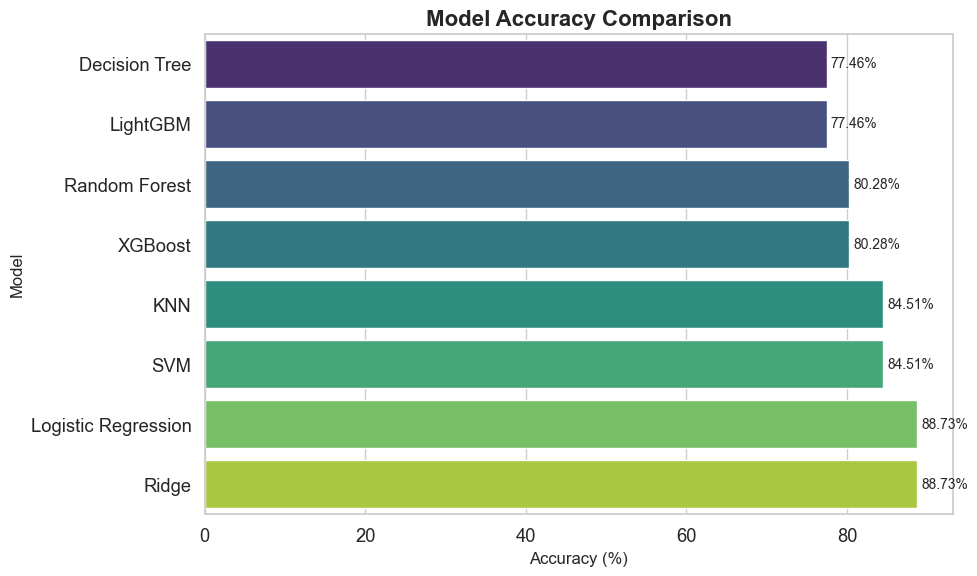

In [108]:
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(10,6))
barplot = sns.barplot(
    x="Accuracy (%)", 
    y="Model", 
    data=results_df.sort_values("Accuracy (%)", ascending=True),
    palette="viridis"
)
plt.title("Model Accuracy Comparison", fontsize=16, weight="bold")
plt.xlabel("Accuracy (%)", fontsize=12)
plt.ylabel("Model", fontsize=12)

for p in barplot.patches:
    plt.text(
        p.get_width() + 0.5,      
        p.get_y() + p.get_height()/2,  
        f"{p.get_width():.2f}%", 
        va="center", fontsize=10
    )

plt.tight_layout()
plt.show()

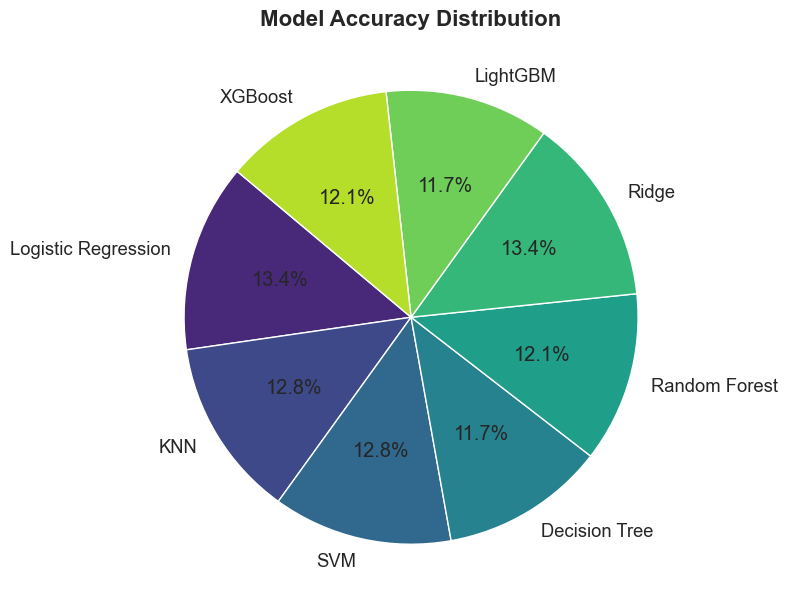

In [109]:
plt.figure(figsize=(8,8))
colors = sns.color_palette("viridis", len(results_df))

plt.pie(
    results_df["Accuracy (%)"],
    labels=results_df["Model"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor":"white","linewidth":1}
)

plt.title("Model Accuracy Distribution", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

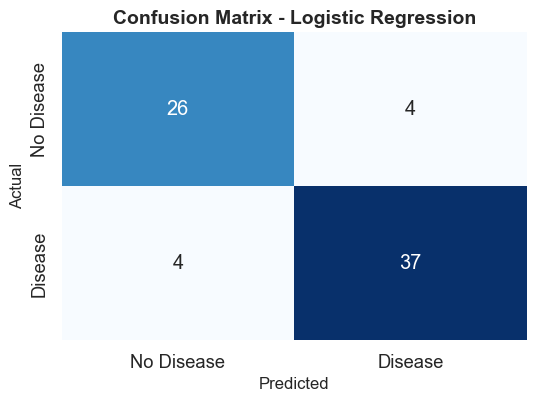

In [110]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix - Logistic Regression", fontsize=14, weight="bold")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.show()

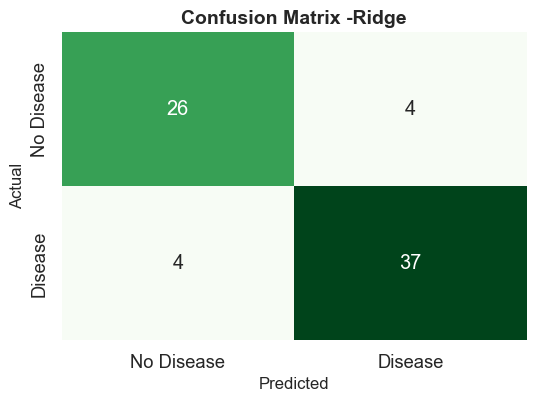

In [111]:
cm_lgbm = confusion_matrix(y_test, y_pred_ridge)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lgbm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix -Ridge", fontsize=14, weight="bold")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.show()